## Task 4 — Feature Correlation Analysis and Logistic Regression Model

This notebook performs the following steps for the MNIST dataset:

- **Correlation analysis** of pixel features
- **Visualization** of correlation patterns
- **Training** a multinomial logistic regression classifier
- **Evaluation** using accuracy and confusion matrix
- **Interpretation** of regression coefficients reshaped into 28×28 images

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import joblib

# Ensure plots show nicely
plt.style.use("seaborn-v0_8")

# Paths
DATA_DIR = os.path.join("..", "data", "processed")
MODELS_DIR = os.path.join("..", "models")
IMAGES_DIR = os.path.join("..", "images")
RESULTS_DIR = os.path.join("..", "results")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

X_train_path = os.path.join(DATA_DIR, "X_train.npy")
X_test_path = os.path.join(DATA_DIR, "X_test.npy")
y_train_path = os.path.join(DATA_DIR, "y_train.npy")
y_test_path = os.path.join(DATA_DIR, "y_test.npy")

X_train = np.load(X_train_path)
X_test = np.load(X_test_path)
y_train = np.load(y_train_path)
y_test = np.load(y_test_path)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (56000, 784)
X_test shape: (14000, 784)
y_train shape: (56000,)
y_test shape: (14000,)


In [2]:
# Flatten images to vectors and (optionally) scale pixel values

n_samples_train = X_train.shape[0]
X_train_flat = X_train.reshape(n_samples_train, -1).astype(np.float32)

n_samples_test = X_test.shape[0]
X_test_flat = X_test.reshape(n_samples_test, -1).astype(np.float32)

# Scale pixel intensities to [0, 1]
X_train_flat /= 255.0
X_test_flat /= 255.0

n_features = X_train_flat.shape[1]
print("Number of features (pixels):", n_features)

Number of features (pixels): 784


Correlation matrix shape: (200, 200)


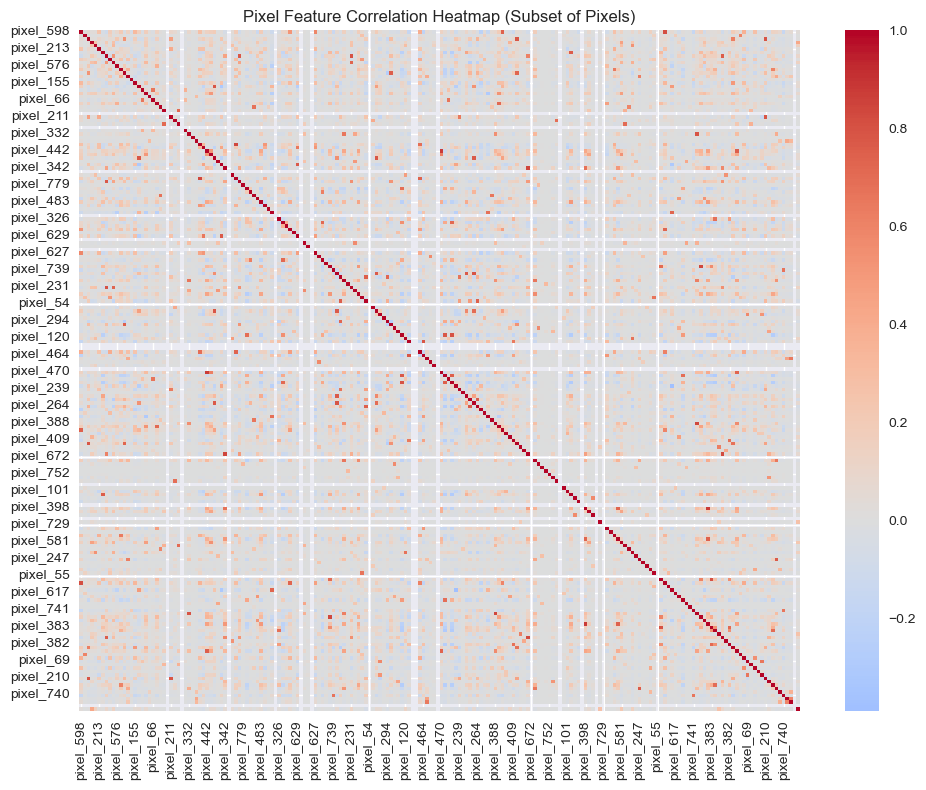

Correlation heatmap saved to: ..\images\correlation_heatmap.png
Observation: neighboring or stroke-related pixels tend to show higher positive correlations.


In [3]:
# Compute Pixel Correlation Matrix on a subset of pixels

# To keep the correlation matrix manageable, select a subset of pixels.
# We choose a fixed random subset for reproducibility.
np.random.seed(42)
subset_size = 200  # you can change this if you want a larger/smaller subset

if subset_size > n_features:
    subset_size = n_features

subset_indices = np.random.choice(n_features, size=subset_size, replace=False)
X_train_subset = X_train_flat[:, subset_indices]

# Use pandas to compute a correlation matrix
subset_columns = [f"pixel_{i}" for i in subset_indices]
df_subset = pd.DataFrame(X_train_subset, columns=subset_columns)

corr_matrix = df_subset.corr()
print("Correlation matrix shape:", corr_matrix.shape)

# Visualize correlation heatmap
plt.figure(figsize=(10, 8))

# Show only a coarse view if matrix is large
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, cbar=True)
plt.title("Pixel Feature Correlation Heatmap (Subset of Pixels)")
plt.tight_layout()

correlation_heatmap_path = os.path.join(IMAGES_DIR, "correlation_heatmap.png")
plt.savefig(correlation_heatmap_path, dpi=150)
plt.show()

print(f"Correlation heatmap saved to: {correlation_heatmap_path}")

# Brief textual observation placeholder
print("Observation: neighboring or stroke-related pixels tend to show higher positive correlations.")

In [4]:
# Train a multinomial logistic regression classifier

log_reg_clf = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    n_jobs=-1,
    verbose=0,
)

log_reg_clf.fit(X_train_flat, y_train)

model_path = os.path.join(MODELS_DIR, "logistic_model.pkl")
joblib.dump(log_reg_clf, model_path)

print(f"Trained logistic regression model saved to: {model_path}")

Trained logistic regression model saved to: ..\models\logistic_model.pkl


Test accuracy: 0.7386
Model accuracy saved to: ..\results\model_accuracy.txt


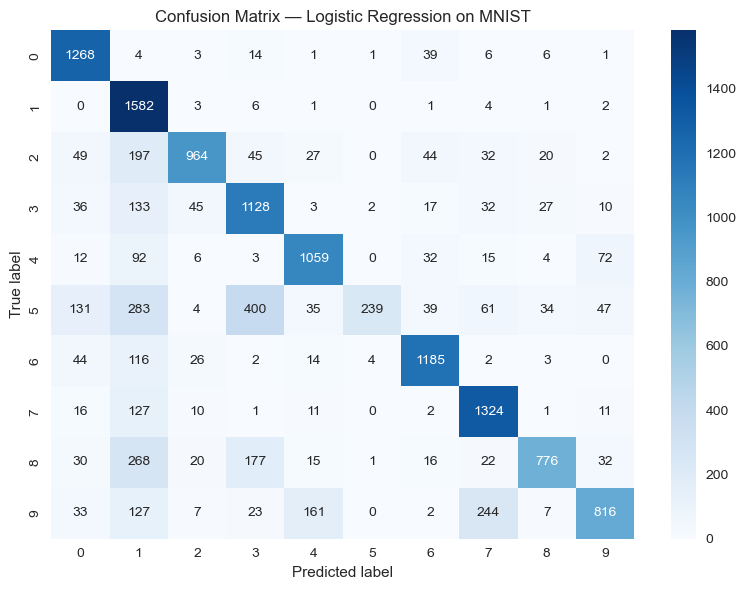

Confusion matrix image saved to: ..\images\confusion_matrix.png
Most frequently confused digit pairs (true, predicted, count):
  5 → 3: 400
  5 → 1: 283
  8 → 1: 268
  9 → 7: 244
  2 → 1: 197


In [5]:
# Evaluate model on test data: accuracy and confusion matrix

y_pred = log_reg_clf.predict(X_test_flat)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.4f}")

# Save accuracy to file
accuracy_path = os.path.join(RESULTS_DIR, "model_accuracy.txt")
with open(accuracy_path, "w") as f:
    f.write(f"Logistic Regression Test Accuracy: {accuracy:.6f}\n")

print(f"Model accuracy saved to: {accuracy_path}")

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — Logistic Regression on MNIST")
plt.tight_layout()

confusion_matrix_path = os.path.join(IMAGES_DIR, "confusion_matrix.png")
plt.savefig(confusion_matrix_path, dpi=150)
plt.show()

print(f"Confusion matrix image saved to: {confusion_matrix_path}")

# Brief textual observations placeholder
most_confused_pairs = []
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0:
            most_confused_pairs.append(((i, j), cm[i, j]))

most_confused_pairs = sorted(most_confused_pairs, key=lambda x: x[1], reverse=True)[:5]
print("Most frequently confused digit pairs (true, predicted, count):")
for (true_d, pred_d), count in most_confused_pairs:
    print(f"  {true_d} → {pred_d}: {count}")

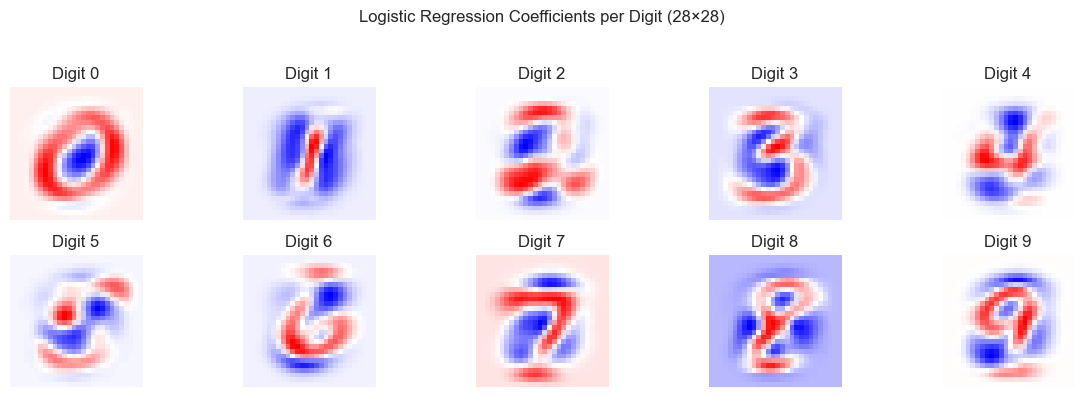

Interpretation: pixels with large positive coefficients (red regions) increase the probability
of predicting that digit when activated, while large negative coefficients (blue regions)
decrease it. These maps highlight which regions of the image are most important for each digit.


In [6]:
# Interpret regression coefficients: reshape into 28×28 images per digit

n_classes = len(np.unique(y_train))

if log_reg_clf.coef_.shape[1] != 28 * 28:
    raise ValueError("Expected 784 features (28x28) for visualization, got "
                     f"{log_reg_clf.coef_.shape[1]}")

coef_images = log_reg_clf.coef_.reshape(n_classes, 28, 28)

plt.figure(figsize=(12, 4))
for digit in range(n_classes):
    plt.subplot(2, 5, digit + 1)
    plt.imshow(coef_images[digit], cmap="bwr")
    plt.title(f"Digit {digit}")
    plt.axis("off")

plt.suptitle("Logistic Regression Coefficients per Digit (28×28)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Interpretation: pixels with large positive coefficients (red regions) increase the probability\n"
      "of predicting that digit when activated, while large negative coefficients (blue regions)\n"
      "decrease it. These maps highlight which regions of the image are most important for each digit.")